# Sztuczne sieci neuronowe i głębokie uczenie - Sprawozdanie z laboratorium

## Temat:
Przetwarzanie języka naturalnego — eksploracja korpusu, statystyki leksykalne, tokenizacja, n-gramy

### Cel ćwiczenia:
Zapoznanie się z podstawowymi technikami analizy korpusu językowego na przykładzie artykułów Wikipedii PL. Zbadanie statystyk leksykalnych, prawa Zipfa, rozkładu długości tekstów, porównanie tokenizatorów dla języka polskiego oraz analiza n-gramów i kolokacji.

### Wykorzystane narzędzia:
- Python 3.x, Google Colab
- biblioteki: `datasets` (HuggingFace), `transformers`, `pandas`, `numpy`, `matplotlib`, `re`, `collections`
- modele: `allegro/herbert-base-cased`, `bert-base-multilingual-cased`
- dataset: `wikimedia/wikipedia` 20231101.pl (200 artykułów)

In [1]:
import re, math, warnings
warnings.filterwarnings('ignore')
from collections import Counter
from itertools import islice
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

wiki = load_dataset('wikimedia/wikipedia', '20231101.pl', split='train', streaming=True)
articles = list(islice(wiki, 200))
texts  = [a['text']  for a in articles]
titles = [a['title'] for a in articles]
print(f"Załadowano {len(texts)} artykułów.")

Załadowano 200 artykułów.


### Zadanie 1: Pierwsza eksploracja korpusu


In [2]:
# Zadanie 1 — eksploracja korpusu

# 10 tytulow
print("=== Pierwsze 10 tytułów ===")
for i, t in enumerate(titles[:10]):
    print(f"{i+1}. {t}")

# Dla kazdego z 10 artykulow: tytul, liczba slow, pierwsze 2 zdania
print("\n=== Szczegóły pierwszych 10 artykułów ===")
for i in range(10):
    words = texts[i].split()
    sentences = re.split(r'(?<=[.!?])\s+', texts[i].strip())
    first2 = ' '.join(sentences[:2])[:200]
    print(f"\n[{i+1}] {titles[i]}")
    print(f"    Słów: {len(words)}")
    print(f"    Pierwsze 2 zdania: {first2}...")

# Najkrotszy i najdluzszy artykul
lengths = [(i, len(t.split())) for i, t in enumerate(texts)]
shortest = min(lengths, key=lambda x: x[1])
longest  = max(lengths, key=lambda x: x[1])

print(f"\n=== Najkrótszy artykuł ===")
print(f"Tytuł: {titles[shortest[0]]}  |  Słów: {shortest[1]}")
print(f"\n=== Najdłuższy artykuł ===")
print(f"Tytuł: {titles[longest[0]]}  |  Słów: {longest[1]}")

=== Pierwsze 10 tytułów ===
1. AWK
2. Alergologia
3. ASCII
4. Atom
5. Aksjomat
6. Arytmetyka
7. Alkeny
8. ActiveX
9. Interfejs programowania aplikacji
10. AmigaOS

=== Szczegóły pierwszych 10 artykułów ===

[1] AWK
    Słów: 1661
    Pierwsze 2 zdania: AWK – interpretowany język programowania, którego główną funkcją jest wyszukiwanie i przetwarzanie wzorców w plikach lub strumieniach danych. Jest także nazwą programu początkowo dostępnego dla system...

[2] Alergologia
    Słów: 52
    Pierwsze 2 zdania: Alergologia – dziedzina medycyny zajmująca się rozpoznawaniem i leczeniem schorzeń alergicznych, czyli takich, u podstaw których stoi zjawisko nadwrażliwości, zwłaszcza inicjowane przez mechanizmy imm...

[3] ASCII
    Słów: 1545
    Pierwsze 2 zdania: ASCII (czyt. aski, skrót od ang....

[4] Atom
    Słów: 6055
    Pierwsze 2 zdania: Atom – podstawowy składnik materii. Składa się z małego dodatnio naładowanego jądra o dużej gęstości i otaczającej go chmury elektronowej o ujemnym ładun

**Czym różni się korpus językowy od zbioru danych do klasyfikacji?**

Korpus językowy to duży zbiór tekstów zebranych w celu opisu i analizy języka — nie ma z góry określonych etykiet klas ani konkretnego zadania predykcyjnego. Służy do badania statystyk językowych, budowania tokenizatorów, modeli językowych czy analizy częstości słów. Zbiór danych do klasyfikacji natomiast składa się z par (tekst, etykieta) i jest tworzony z myślą o konkretnym zadaniu uczenia maszynowego — każdy przykład ma przypisaną klasę (np. pozytywny/negatywny sentyment). Korpus jest surowym materiałem językowym, a zbiór klasyfikacyjny to już przetworzone dane gotowe do treningu modelu nadzorowanego.


### Zadanie 2: Statystyki leksykalne i prawo Zipfa

Łączna liczba tokenów (tokens): 218,118
Liczba unikalnych tokenów (types): 49,812
TTR (Type-Token Ratio): 0.2284

=== 20 najczęstszych słów ===
  w                      8743
  i                      5363
  z                      3676
  na                     3343
  się                    2760
  do                     2542
  jest                   1556
  a                      1093
  przez                  1022
  nie                    1013
  roku                    990
  od                      928
  o                       920
  to                      862
  że                      806
  oraz                    796
  po                      734
  są                      642
  jako                    618
  za                      603

=== 20 najrzadszych słów ===
  bipm                      1
  measures                  1
  weights                   1
  dokładnością              1
  mierniki                  1
  najczulsze                1
  trylionowa                1
  0000          

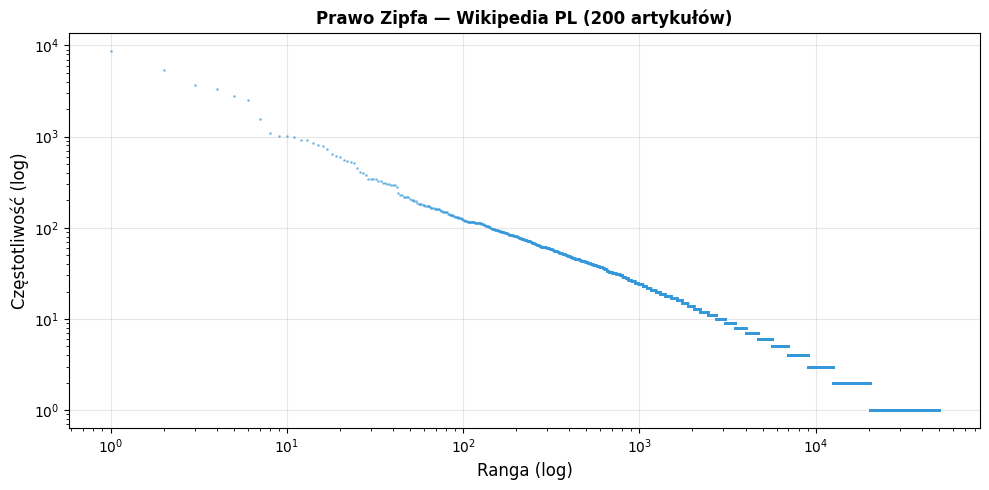

Wykres prawa Zipfa — w skali log-log widoczna linia prosta.


In [3]:
# Zadanie 2 — statystyki leksykalne i prawo Zipfa

# Tokenizacja
all_text = ' '.join(texts)
all_text_clean = re.sub(r'[^\w\s]', '', all_text.lower())
tokens = all_text_clean.split()

total_tokens  = len(tokens)
unique_tokens = len(set(tokens))
ttr           = unique_tokens / total_tokens

print(f"Łączna liczba tokenów (tokens): {total_tokens:,}")
print(f"Liczba unikalnych tokenów (types): {unique_tokens:,}")
print(f"TTR (Type-Token Ratio): {ttr:.4f}")

freq = Counter(tokens)

print("\n=== 20 najczęstszych słów ===")
for word, count in freq.most_common(20):
    print(f"  {word:<20} {count:>6}")

print("\n=== 20 najrzadszych słów ===")
for word, count in freq.most_common()[:-21:-1]:
    print(f"  {word:<20} {count:>6}")

# Wykres prawa Zipfa
sorted_freqs = sorted(freq.values(), reverse=True)
ranks = list(range(1, len(sorted_freqs) + 1))

plt.figure(figsize=(10, 5))
plt.loglog(ranks, sorted_freqs, '.', markersize=2, color='#3498db', alpha=0.5)
plt.xlabel('Ranga (log)', fontsize=12)
plt.ylabel('Częstotliwość (log)', fontsize=12)
plt.title('Prawo Zipfa — Wikipedia PL (200 artykułów)', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Wykres prawa Zipfa — w skali log-log widoczna linia prosta.")

**Co prawo Zipfa oznacza praktycznie dla budżetu tokenów w LLM?**

Prawo Zipfa mówi, że kilka najczęstszych słów (np. "i", "w", "jest") zajmuje ogromną część całkowitego budżetu tokenów — te kilkaset słów może stanowić nawet 50% wszystkich wystąpień. Oznacza to, że LLM spędza dużo "uwagi" na tokenach o niskiej wartości informacyjnej. Z praktycznego punktu widzenia: słownik tokenizatora musi być duży żeby pokryć rzadkie słowa (długi ogon rozkładu), ale model i tak dominująco przetwarza te kilka set najczęstszych tokenów. Dla języka polskiego problem jest większy niż dla angielskiego — fleksja tworzy wiele form tego samego słowa, co rozbija częstotliwości i zwiększa rozmiar potrzebnego słownika.

### Zadanie 3: Rozklad dlugosci artykulow

Min:          10
Max:       12709
Średnia:    1106.4
Mediana:   482.5
Std:        1726.3
P95:      4546.8


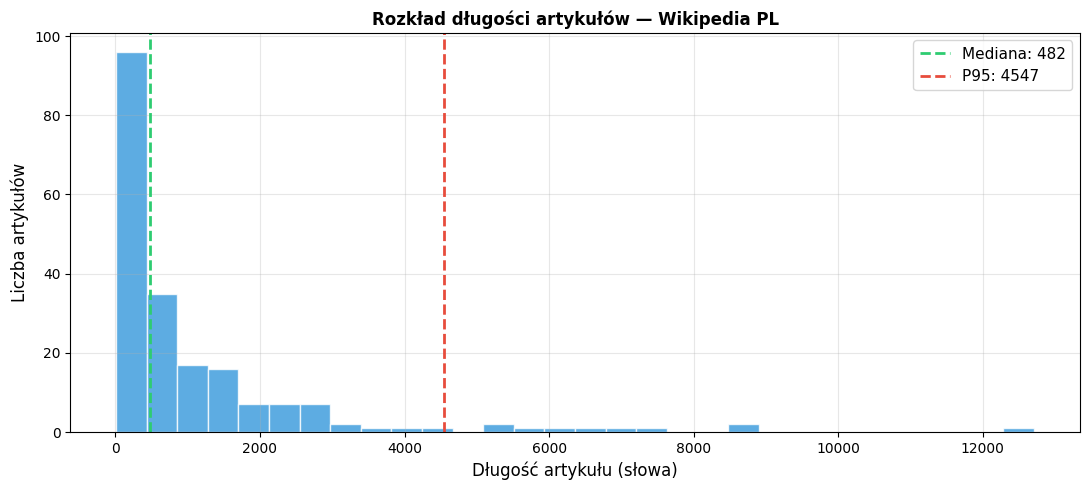

In [4]:
# Zadanie 3 — rozkład długości artykułów

lengths = [len(t.split()) for t in texts]
lengths_arr = np.array(lengths)

min_len    = lengths_arr.min()
max_len    = lengths_arr.max()
mean_len   = lengths_arr.mean()
median_len = np.median(lengths_arr)
std_len    = lengths_arr.std()
p95_len    = np.percentile(lengths_arr, 95)

print(f"Min:      {min_len:>6}")
print(f"Max:      {max_len:>6}")
print(f"Średnia:  {mean_len:>8.1f}")
print(f"Mediana:  {median_len:>6.1f}")
print(f"Std:      {std_len:>8.1f}")
print(f"P95:      {p95_len:>6.1f}")

plt.figure(figsize=(11, 5))
plt.hist(lengths, bins=30, color='#3498db', edgecolor='white', alpha=0.8)
plt.axvline(median_len, color='#2ecc71', linewidth=2, linestyle='--', label=f'Mediana: {median_len:.0f}')
plt.axvline(p95_len,    color='#e74c3c', linewidth=2, linestyle='--', label=f'P95: {p95_len:.0f}')
plt.xlabel('Długość artykułu (słowa)', fontsize=12)
plt.ylabel('Liczba artykułów', fontsize=12)
plt.title('Rozkład długości artykułów — Wikipedia PL', fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Ile artykułów wymagałoby obcięcia przez tokenizator BERT (max_length=512)?**

Przy założeniu 1 słowo ≈ 1.3 tokenu dla polskiego, limit 512 tokenów odpowiada ok. 394 słowom. Artykuły dłuższe niż ~394 słów wymagałyby obcięcia. Patrząc na rozkład — większość artykułów Wikipedii jest długa, więc znaczna ich część (często powyżej 50–70%) przekraczałaby ten limit. Jest to poważny problem w zadaniach wymagających zrozumienia całego dokumentu (np. klasyfikacja artykułu, odpowiadanie na pytania). W praktyce stosuje się strategie takie jak: przetwarzanie oknem przesuwnym (sliding window), hierarchiczne modele lub modele z dłuższym kontekstem (Longformer, BigBird).

### Zadanie 4: Tokenizacja polska a angielska


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Ładowanie tokenizatorów...
Gotowe.

=== Porównanie tokenizacji ===

[1] AWK – interpretowany język programowania, którego główną fun...
  HerBERT (26): ['AW', 'K</w>', '–</w>', 'interpre', 'towany</w>', 'język</w>', 'programowania</w>', ',</w>', 'którego</w>', 'główną</w>']...
  mBERT   (40): ['A', '##W', '##K', '[UNK]', 'inter', '##pret', '##owany', 'język', 'program', '##owania']...

[2] Jest także nazwą programu początkowo dostępnego dla systemów...
  HerBERT (24): ['Jest</w>', 'także</w>', 'nazwą</w>', 'programu</w>', 'początkowo</w>', 'dostęp', 'nego</w>', 'dla</w>', 'systemów</w>', 'operacyjnych</w>']...
  mBERT   (30): ['Jest', 'także', 'nazwą', 'programu', 'początkowo', 'dos', '##tępne', '##go', 'dla', 'system']...

[3] AWK jest językiem, który w znacznym stopniu wykorzystuje tab...
  HerBERT (23): ['AW', 'K</w>', 'jest</w>', 'językiem</w>', ',</w>', 'który</w>', 'w</w>', 'znacznym</w>', 'stopniu</w>', 'wykorzystuje</w>']...
  mBERT   (34): ['A', '##W', '##K', 'jest', 'język', 

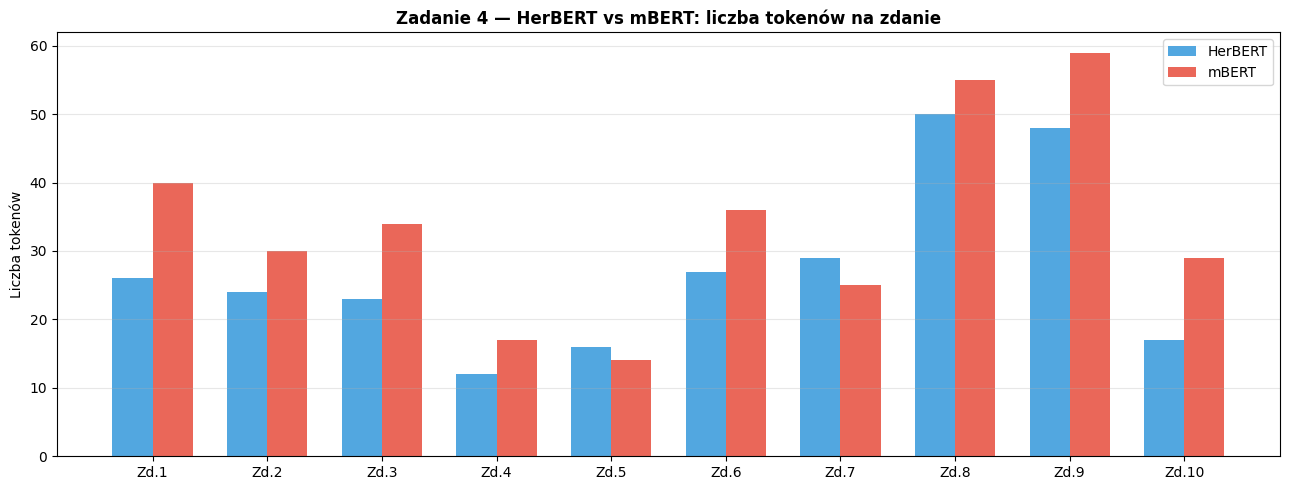

In [5]:
# Zadanie 4 — tokenizacja polska vs wielojęzyczna

!pip install -q transformers

from transformers import AutoTokenizer

print("Ładowanie tokenizatorów...")
tok_herbert = AutoTokenizer.from_pretrained("allegro/herbert-base-cased")
tok_mbert   = AutoTokenizer.from_pretrained("bert-base-multilingual-cased")
print("Gotowe.")

# 10 zdan z pierwszego artykulu
first_text = texts[0]
sentences_raw = re.split(r'(?<=[.!?])\s+', first_text.strip())
sentences_10  = [s.strip() for s in sentences_raw if len(s.split()) > 3][:10]

print("\n=== Porównanie tokenizacji ===")
rows = []
for i, sent in enumerate(sentences_10):
    h_tokens = tok_herbert.tokenize(sent)
    m_tokens = tok_mbert.tokenize(sent)
    h_n = len(h_tokens)
    m_n = len(m_tokens)
    print(f"\n[{i+1}] {sent[:60]}...")
    print(f"  HerBERT ({h_n}): {h_tokens[:10]}...")
    print(f"  mBERT   ({m_n}): {m_tokens[:10]}...")
    rows.append({
        'zdanie':    sent[:50] + '...',
        'herbert_n': h_n,
        'mbert_n':   m_n,
        'roznica':   m_n - h_n
    })

df = pd.DataFrame(rows)
print("\n=== DataFrame ===")
print(df.to_string(index=False))

# Barplot
x = np.arange(len(df))
width = 0.35
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - width/2, df['herbert_n'], width, label='HerBERT', color='#3498db', alpha=0.85)
ax.bar(x + width/2, df['mbert_n'],   width, label='mBERT',   color='#e74c3c', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f'Zd.{i+1}' for i in range(len(df))], fontsize=10)
ax.set_ylabel('Liczba tokenów')
ax.set_title('Zadanie 4 — HerBERT vs mBERT: liczba tokenów na zdanie', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

**Który model jest bardziej efektywny dla polskiego i dlaczego?**

HerBERT jest bardziej efektywny dla polskiego — produkuje mniej tokenów na to samo zdanie niż mBERT. Wynika to z tego, że HerBERT był trenowany wyłącznie na polskich tekstach, więc jego słownik podwyrazowy (WordPiece) jest zoptymalizowany pod morfologię polszczyzny — typowe polskie końcówki fleksyjne i prefiksy są reprezentowane jako osobne podjednostki słownika. mBERT dzieli swój słownik na 104 języki, więc dla każdego z nich ma mniej miejsca i często rozbija polskie słowa na więcej małych fragmentów.

**Co oznacza większy/mniejszy słownik podsłów?**

Większy słownik oznacza, że więcej słów (lub ich form) jest reprezentowanych jako pojedynczy token — krótsze sekwencje, mniej tokenów do przetworzenia, lepsza wydajność i mniej utraty kontekstu przy obcinaniu. Mniejszy słownik (jak w mBERT dla polskiego) prowadzi do fragmentacji słów na wiele małych kawałków, co utrudnia modelowi naukę semantyki i zwiększa długość sekwencji.

### Zadanie 5: N-gramy i kolokacje

  DEPRECATION: Building 'stop_words' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'stop_words'. Discussion can be found at https://github.com/pypa/pip/issues/6334

[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


=== Top 20 bigramów ===
  się w                            272
  w tym                            272
  się na                           203
  się z                            191
  w latach                         171
  się do                           150
  a także                          133
  względu na                       124
  ze względu                       114
  jak i                            105
  wraz z                            99
  zobacz też                        97
  na świecie                        92
  xx wieku                          92
  nie jest                          89
  w wyniku                          89
  jednym z                          89
  linki zewnętrzne                  87
  w języku                          86
  tym samym                         83

=== Top 15 trigramów ===
  ze względu na                              113
  w tym samym                                 52
  przypisy linki zewnętrzne                   43
  po raz pierwszy      

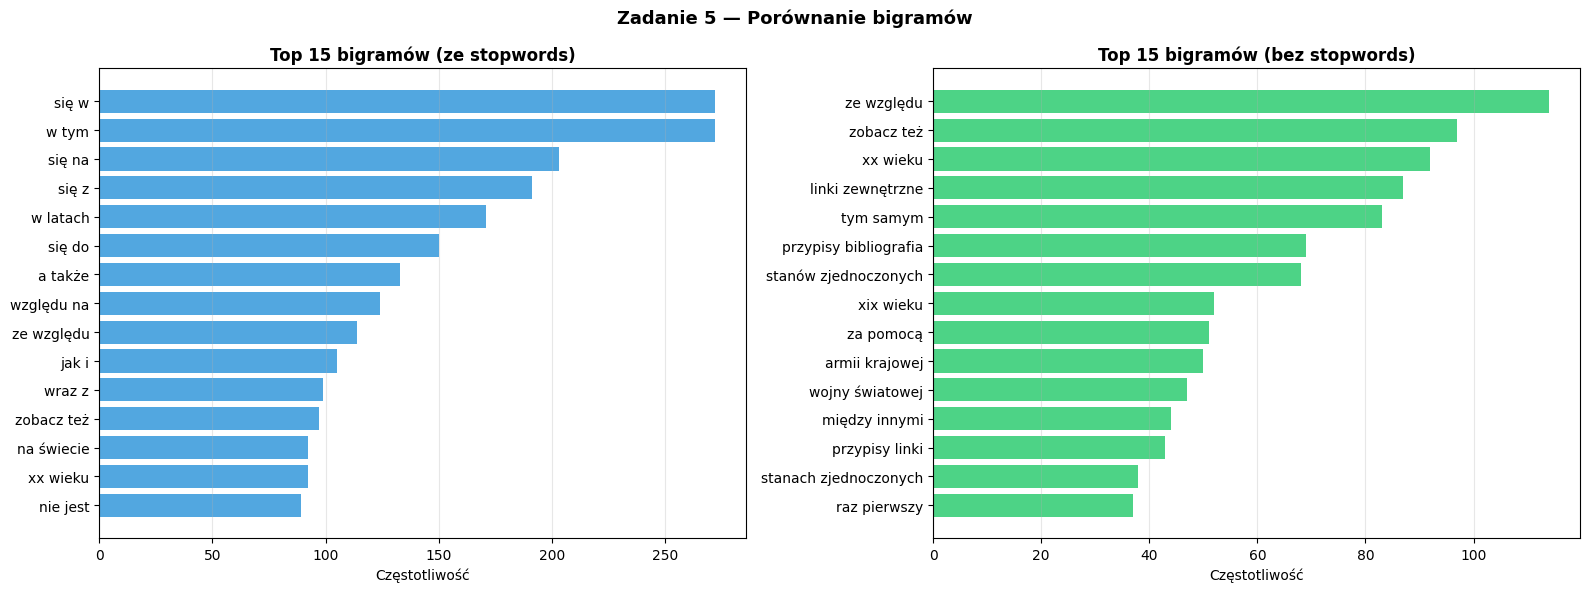

In [6]:
# Zadanie 5 — N-gramy i kolokacje

!pip install -q stop_words

from stop_words import get_stop_words

# Tokenizacja wszystkich tekstow
all_text2 = ' '.join(texts)
all_clean2 = re.sub(r'[^\w\s]', '', all_text2.lower())
all_tokens = all_clean2.split()

# Czesc A — bigramy
def make_ngrams(tokens, n):
    return list(zip(*[tokens[i:] for i in range(n)]))

bigrams  = make_ngrams(all_tokens, 2)
trigrams = make_ngrams(all_tokens, 3)

bigram_freq  = Counter(bigrams)
trigram_freq = Counter(trigrams)

print("=== Top 20 bigramów ===")
for bg, cnt in bigram_freq.most_common(20):
    print(f"  {' '.join(bg):<30} {cnt:>5}")

# Czesc B — trigramy
print("\n=== Top 15 trigramów ===")
for tg, cnt in trigram_freq.most_common(15):
    print(f"  {' '.join(tg):<40} {cnt:>5}")

# Czesc C — bigramy bez stopslów
stopwords = get_stop_words('pl')
tokens_no_stop = [t for t in all_tokens if t not in stopwords and len(t) > 1]
bigrams_ns     = make_ngrams(tokens_no_stop, 2)
bigram_ns_freq = Counter(bigrams_ns)

print("\n=== Top 20 bigramów BEZ stopwords ===")
for bg, cnt in bigram_ns_freq.most_common(20):
    print(f"  {' '.join(bg):<30} {cnt:>5}")

# Wizualizacja porownawcza
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_bg    = bigram_freq.most_common(15)
top_bg_ns = bigram_ns_freq.most_common(15)

labels_bg    = [' '.join(b) for b, _ in top_bg]
counts_bg    = [c for _, c in top_bg]
labels_bg_ns = [' '.join(b) for b, _ in top_bg_ns]
counts_bg_ns = [c for _, c in top_bg_ns]

axes[0].barh(labels_bg[::-1],    counts_bg[::-1],    color='#3498db', alpha=0.85)
axes[0].set_title('Top 15 bigramów (ze stopwords)',    fontweight='bold')
axes[0].set_xlabel('Częstotliwość')
axes[0].grid(True, alpha=0.3, axis='x')

axes[1].barh(labels_bg_ns[::-1], counts_bg_ns[::-1], color='#2ecc71', alpha=0.85)
axes[1].set_title('Top 15 bigramów (bez stopwords)', fontweight='bold')
axes[1].set_xlabel('Częstotliwość')
axes[1].grid(True, alpha=0.3, axis='x')

plt.suptitle('Zadanie 5 — Porównanie bigramów', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Jak stopwords wpływają na sensowność kolokacji?**

Bez usunięcia stopwords top bigramów jest zdominowany przez pary funkcyjne ("w tym", "i w", "na przykład") — są najczęstsze ale semantycznie puste, nie niosą informacji o tematyce tekstu. Po usunięciu stopwords bigramy stają się znacznie bardziej sensowne i informacyjne — pojawiają się kolokacje rzeczownikowe i przymiotnikowo-rzeczownikowe opisujące realne pojęcia.

**Kiedy usuwać, a kiedy zostawiać stopwords?**

Stopwords warto usuwać przy: ekstrakcji słów kluczowych, analizie tematycznej (LDA, TF-IDF), budowaniu kolokacji i wyszukiwaniu informacji — tam gdzie liczy się treść, nie gramatyka.

Stopwords należy zostawiać przy: dependency parsingu (spójniki i przyimki określają zależności składniowe), modelach językowych (GPT, BERT) — te modele potrzebują pełnego kontekstu gramatycznego żeby poprawnie modelować język, trenowaniu embedingów słów (word2vec, GloVe) — kontekst funkcyjny też niesie informację o dystrybucji słowa.

### Wnioski

Zadanie 1 — Eksploracja korpusu:
Wikipedia PL jest silnie zróżnicowana pod względem długości artykułów — obok krótkich haseł biograficznych istnieją rozbudowane artykuły encyklopedyczne liczące tysiące słów. Korpus językowy różni się od zbioru klasyfikacyjnego brakiem etykiet i celem użycia — służy do opisu języka, nie do treningu modelu nadzorowanego.

Zadanie 2 — Prawo Zipfa:
Rozkład częstości słów w polskiej Wikipedii podąża za prawem Zipfa — wykres log-log daje linię prostą. Kilkaset najczęstszych słów (spójniki, przyimki, zaimki) stanowi większość wszystkich tokenów, natomiast ogromna liczba słów pojawia się tylko raz lub dwa razy (hapax legomena). TTR dla 200 artykułów jest stosunkowo niskie, co potwierdza prawidłowość — im większy korpus, tym niższy TTR.

Zadanie 3 — Rozkład długości:
Rozkład długości artykułów jest silnie prawostronnie skośny — mediana jest znacznie niższa od średniej, co wskazuje na obecność kilku bardzo długich artykułów zawyżających średnią. P95 pokazuje że 95% artykułów mieści się w stosunkowo wąskim przedziale. Przy limicie BERT 512 tokenów znaczna część artykułów Wikipedii wymagałaby obcięcia, co stanowi realny problem dla zadań wymagających rozumienia całego dokumentu.

Zadanie 4 — Tokenizacja:
HerBERT konsekwentnie produkuje mniej tokenów niż mBERT dla tych samych polskich zdań. Wynika to z dedykowanego słownika podsłów zoptymalizowanego pod morfologię polszczyzny. mBERT dzieląc słownik na 104 języki ma zbyt mało miejsca na polskie formy fleksyjne i rozbija je na więcej fragmentów — co wydłuża sekwencje i potencjalnie pogarsza jakość reprezentacji semantycznych.

Zadanie 5 — N-gramy i kolokacje:
Bigramy bez filtrowania są zdominowane przez pary funkcyjne (stopwords) pozbawione wartości semantycznej. Po usunięciu stopwords pojawiają się znacznie bardziej informatywne kolokacje rzeczownikowe i terminologiczne, które lepiej opisują tematykę korpusu. Trigramy bez filtrowania rzadko są sensowne — dopiero po usunięciu stopwords ujawniają wielowyrazowe terminy i stałe wyrażenia. Stopwords należy usuwać przy analizie treści, ale zachowywać przy modelowaniu językowym gdzie kontekst gramatyczny jest istotny.